# Stage 2 — Meta-Learning Experiment Controller

**YAML is the single source of truth.** Do not hardcode experiment parameters here — change `PRESET` in the section controls cell and run the corresponding runner cell.

Sections 3–8 mirror the four YAML experiment groups. Sections 9–10 cover post-run inspection and artifact validation.

Analysis and publication-quality plots live in `17.1_stage2_analysis_dashboard.ipynb`.

## 1. Setup and Config Loading

In [1]:
from __future__ import annotations

import importlib.util
import sys
import warnings
from pathlib import Path

import pandas as pd

warnings.filterwarnings("ignore", category=UserWarning)
warnings.filterwarnings("ignore", category=FutureWarning)

# Project paths (notebook can be opened from repo root or notebooks/).
PROJECT_ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
SRC_PATH = PROJECT_ROOT / "src"
EXPERIMENTS_PATH = PROJECT_ROOT / "experiments"
EXPERIMENT_ROOT = PROJECT_ROOT / "models" / "stage_2" / "experiments"
CONFIG_PATH = PROJECT_ROOT / "experiments" / "stage2_config.yaml"

for _p in [str(SRC_PATH), str(PROJECT_ROOT)]:
    if _p not in sys.path:
        sys.path.insert(0, _p)

from master_thesis.stage2 import (
    GLOBAL_INIT_NAMES,
    SUPPORTED_INIT_NAMES,
    TARGET_AWARE_INIT_NAMES,
    backfill_legacy_stage2_results,
    build_experiment_preview_df,
    discover_stage1_artifacts,
    load_stage2_config,
    resolve_experiment_grid,
    stage1_artifact_inventory,
    validate_experiment_grid,
)
from master_thesis.plotting import plot_stage2_metric_comparison, set_thesis_style

set_thesis_style(palette="dtu", font_scale=1.05, grid=False)


def _load_run_experiments():
    """Lazily import the CLI runner so the notebook does not require the
    `experiments/` directory to be on `sys.path`."""
    spec = importlib.util.spec_from_file_location(
        "run_stage2", EXPERIMENTS_PATH / "run_stage2.py"
    )
    module = importlib.util.module_from_spec(spec)
    spec.loader.exec_module(module)
    return module.run_experiments


print(f"Project root: {PROJECT_ROOT}")
print(f"Config path:  {CONFIG_PATH}")
print(f"Config exists: {CONFIG_PATH.exists()}")

Project root: /Users/Thomas/Desktop/Master Thesis
Config path:  /Users/Thomas/Desktop/Master Thesis/experiments/stage2_config.yaml
Config exists: True


In [2]:
inventory = stage1_artifact_inventory()
print("Targets with the full B/C/D set available:", inventory["targets_with_full_set"])
print(f"Runnable cells: {len(inventory['runnable'])}")
print(f"Missing cells:  {len(inventory['missing'])}")
display(inventory["df"])

Targets with the full B/C/D set available: ['Logistics', 'Packaging Material']
Runnable cells: 7
Missing cells:  0


,init_name,target_department,scope,artifact_dir,has_model,has_preprocessor,is_runnable
0,A_weak_only,NaN,global,/Users/Thomas/Desktop/Master Thesis/models/sta...,True,True,True
1,B_gold_only,Logistics,target_aware,/Users/Thomas/Desktop/Master Thesis/models/sta...,True,True,True
2,C_hybrid,Logistics,target_aware,/Users/Thomas/Desktop/Master Thesis/models/sta...,True,True,True
3,D_hybrid_unweighted,Logistics,target_aware,/Users/Thomas/Desktop/Master Thesis/models/sta...,True,True,True
4,B_gold_only,Packaging Material,target_aware,/Users/Thomas/Desktop/Master Thesis/models/sta...,True,True,True
5,C_hybrid,Packaging Material,target_aware,/Users/Thomas/Desktop/Master Thesis/models/sta...,True,True,True
6,D_hybrid_unweighted,Packaging Material,target_aware,/Users/Thomas/Desktop/Master Thesis/models/sta...,True,True,True


## 2. Available Experiment Presets

The table below lists all 10 canonical presets in their four YAML groups. Scroll to the corresponding section (3–8) to run a group, or use the CLI commands directly.

| Group | PRESET | Purpose | CLI |
|-------|--------|---------|-----|
| **Group 1 — Debug** | `quick_debug` | Fast smoke test (2 repeats, 5 steps) | `--preset quick_debug` |
| **Group 1 — Debug** | `stage2b_debug` | Stage 2b smoke test (synth augmentation) | `--preset stage2b_debug` |
| **Group 2 — Main** | `thesis_main` | Primary comparison: zero_shot / finetune / ANIL / FOMAML / MAML | `--preset thesis_main` |
| **Group 2 — Main** | `init_ablation` | Initialization source ablation (A/B/C/D/random) | `--preset init_ablation` |
| **Group 2 — Main** | `k_shot_label_budget` | k=1 and k=2 feasible label-budget curve | `--preset k_shot_label_budget` |
| **Group 3 — MAML** | `maml_lr_sweep` | Inner-LR × inner-step sweep for MAML family | `--preset maml_lr_sweep` |
| **Group 3 — MAML** | `maml_freeze_ablation` | ⚠ TODO — requires freeze scope in `_run_meta_method()` | *(not runnable)* |
| **Group 3 — MAML** | `maml_mechanics_debug` | ⚠ TODO — requires freeze scope in `_run_meta_method()` | *(not runnable)* |
| **Group 4 — Stage 2b** | `stage2b_smotenc` | SMOTENC support augmentation (canonical Stage 2b) | `--preset stage2b_smotenc` |
| **Group 4 — Stage 2b** | `stage2b_label_budget` | Stage 2b with k-shot label budget sweep | `--preset stage2b_label_budget` |

**Full CLI pattern:**
```bash
PYTHONPATH=src .venv/bin/python experiments/run_stage2.py --preset <PRESET> [--force-rerun] [--preview-only]
```

## 3. Debug / Smoke Tests

Use `quick_debug` to verify the pipeline end-to-end without spending compute (2 repeats, 5 inner steps, Logistics only). Use `stage2b_debug` to verify the Stage 2b SMOTENC augmentation path.

**When to use:** After any code change to `stage2.py`, `run_stage2.py`, or the YAML config.

In [3]:
# ── Group 1 Controls — Debug / Smoke Tests ──────────────────────────────────
PRESET = "quick_debug"   # Options: "quick_debug", "stage2b_debug"

RUN_EXPERIMENTS = False  # Set True to execute
FORCE_RERUN = False      # Set True to rerun even if artifacts already exist
DROP_INVALID_CELLS = True

# Optional grid overrides (None = inherit from the preset)
METHODS_OVERRIDE = None
SUPPORT_GRID_OVERRIDE = None
INNER_STEPS_OVERRIDE = None
INIT_NAMES_OVERRIDE = None
TARGET_DEPARTMENTS_OVERRIDE = None
PRESET_META_OVERRIDES = None

In [4]:
# ── Resolve experiment grid ──────────────────────────────────────────────────
_full_config = load_stage2_config(CONFIG_PATH)

_override_payload = {}
if METHODS_OVERRIDE is not None:
    _override_payload["methods"] = METHODS_OVERRIDE
if SUPPORT_GRID_OVERRIDE is not None:
    _override_payload["support_grid"] = SUPPORT_GRID_OVERRIDE
if INNER_STEPS_OVERRIDE is not None:
    _override_payload["inner_steps_grid"] = INNER_STEPS_OVERRIDE
if INIT_NAMES_OVERRIDE is not None:
    _override_payload["init_names"] = INIT_NAMES_OVERRIDE
if TARGET_DEPARTMENTS_OVERRIDE is not None:
    _override_payload["target_departments"] = TARGET_DEPARTMENTS_OVERRIDE
if PRESET_META_OVERRIDES is not None:
    _override_payload.update(PRESET_META_OVERRIDES)

_exp_list = resolve_experiment_grid(
    full_config=_full_config,
    preset_name=PRESET,
    overrides=_override_payload,
)
_preview_df = build_experiment_preview_df(_exp_list)
_exp_ids = [eid for eid, _ in _exp_list]

print(f"Preset:               {PRESET}")
print(f"Run experiments:      {RUN_EXPERIMENTS}")
print(f"Force rerun:          {FORCE_RERUN}")
print(f"Resolved experiments: {len(_preview_df)}")
display(_preview_df)

# ── Equivalent CLI command ───────────────────────────────────────────────────
_force_flag = " --force-rerun" if FORCE_RERUN else ""
_preview_flag = "" if RUN_EXPERIMENTS else " --preview-only"
print()
print("=" * 70)
print("Equivalent CLI command:")
print(f"  PYTHONPATH=src .venv/bin/python experiments/run_stage2.py "
      f"--preset {PRESET}{_force_flag}{_preview_flag}")
print("=" * 70)

# ── Pre-flight validation ────────────────────────────────────────────────────
_runnable_list, _preflight_report = validate_experiment_grid(
    _exp_list,
    drop_invalid=DROP_INVALID_CELLS,
    verbose=True,
)
print(f"\nPre-flight: {_preflight_report['is_runnable'].sum()} runnable / {len(_preflight_report)} total")

# ── Execute ──────────────────────────────────────────────────────────────────
if RUN_EXPERIMENTS and len(_runnable_list) > 0:
    run_experiments = _load_run_experiments()
    _results = run_experiments(
        experiment_list=_runnable_list,
        skip_if_exists=not FORCE_RERUN,
        force_rerun=FORCE_RERUN,
        verbose=True,
    )
    print(f"Completed {len(_results)} experiment rows.")
else:
    print("\nExecution skipped. Set RUN_EXPERIMENTS = True to dispatch the resolved cells.")


Preset:               quick_debug
Run experiments:      False
Force rerun:          False
Resolved experiments: 2


,experiment_id,method,n_support_pos,n_support_neg,inner_steps,init_name,target_department,data_filename,synthetic_proportion,augmentation_method,target_per_class,k_neighbors
0,stage2__init-A_weak_only__method-finetune__kpo...,finetune,2,2,3,A_weak_only,Logistics,contract_with_features_labeled_with_gold.csv,0.0,none,None,5
1,stage2__init-A_weak_only__method-anil__kpos-2_...,anil,2,2,3,A_weak_only,Logistics,contract_with_features_labeled_with_gold.csv,0.0,none,None,5



Equivalent CLI command:
  PYTHONPATH=src .venv/bin/python experiments/run_stage2.py --preset quick_debug --preview-only

Pre-flight: 2 runnable / 2 total

Execution skipped. Set RUN_EXPERIMENTS = True to dispatch the resolved cells.


## 4. Main Thesis Experiments

`thesis_main` is the primary method comparison. It runs all five methods (zero_shot, finetune, ANIL, FOMAML, MAML) across all four departments, k=1 and k=2 support, and the canonical inner-step counts. Results feed directly into Table 1 and Figure 3 of the thesis.

`init_ablation` holds methods fixed (ANIL) and varies the Stage 1 initialization source (A_weak_only / B_gold_only / C_hybrid / D_hybrid_unweighted / random) to answer Research Question 4.

In [5]:
# ── Group 2 Controls — Main Thesis Experiments ──────────────────────────────
PRESET = "thesis_main"   # Options: "thesis_main", "init_ablation"

RUN_EXPERIMENTS = False  # Set True to execute
FORCE_RERUN = False      # Set True to rerun even if artifacts already exist
DROP_INVALID_CELLS = True

# Optional grid overrides (None = inherit from the preset)
METHODS_OVERRIDE = None
SUPPORT_GRID_OVERRIDE = None
INNER_STEPS_OVERRIDE = None
INIT_NAMES_OVERRIDE = None
TARGET_DEPARTMENTS_OVERRIDE = None
PRESET_META_OVERRIDES = None

In [6]:
# ── Resolve experiment grid ──────────────────────────────────────────────────
_full_config = load_stage2_config(CONFIG_PATH)

_override_payload = {}
if METHODS_OVERRIDE is not None:
    _override_payload["methods"] = METHODS_OVERRIDE
if SUPPORT_GRID_OVERRIDE is not None:
    _override_payload["support_grid"] = SUPPORT_GRID_OVERRIDE
if INNER_STEPS_OVERRIDE is not None:
    _override_payload["inner_steps_grid"] = INNER_STEPS_OVERRIDE
if INIT_NAMES_OVERRIDE is not None:
    _override_payload["init_names"] = INIT_NAMES_OVERRIDE
if TARGET_DEPARTMENTS_OVERRIDE is not None:
    _override_payload["target_departments"] = TARGET_DEPARTMENTS_OVERRIDE
if PRESET_META_OVERRIDES is not None:
    _override_payload.update(PRESET_META_OVERRIDES)

_exp_list = resolve_experiment_grid(
    full_config=_full_config,
    preset_name=PRESET,
    overrides=_override_payload,
)
_preview_df = build_experiment_preview_df(_exp_list)
_exp_ids = [eid for eid, _ in _exp_list]

print(f"Preset:               {PRESET}")
print(f"Run experiments:      {RUN_EXPERIMENTS}")
print(f"Force rerun:          {FORCE_RERUN}")
print(f"Resolved experiments: {len(_preview_df)}")
display(_preview_df)

# ── Equivalent CLI command ───────────────────────────────────────────────────
_force_flag = " --force-rerun" if FORCE_RERUN else ""
_preview_flag = "" if RUN_EXPERIMENTS else " --preview-only"
print()
print("=" * 70)
print("Equivalent CLI command:")
print(f"  PYTHONPATH=src .venv/bin/python experiments/run_stage2.py "
      f"--preset {PRESET}{_force_flag}{_preview_flag}")
print("=" * 70)

# ── Pre-flight validation ────────────────────────────────────────────────────
_runnable_list, _preflight_report = validate_experiment_grid(
    _exp_list,
    drop_invalid=DROP_INVALID_CELLS,
    verbose=True,
)
print(f"\nPre-flight: {_preflight_report['is_runnable'].sum()} runnable / {len(_preflight_report)} total")

# ── Execute ──────────────────────────────────────────────────────────────────
if RUN_EXPERIMENTS and len(_runnable_list) > 0:
    run_experiments = _load_run_experiments()
    _results = run_experiments(
        experiment_list=_runnable_list,
        skip_if_exists=not FORCE_RERUN,
        force_rerun=FORCE_RERUN,
        verbose=True,
    )
    print(f"Completed {len(_results)} experiment rows.")
else:
    print("\nExecution skipped. Set RUN_EXPERIMENTS = True to dispatch the resolved cells.")


Preset:               thesis_main
Run experiments:      False
Force rerun:          False
Resolved experiments: 80


,experiment_id,method,n_support_pos,n_support_neg,inner_steps,init_name,target_department,data_filename,synthetic_proportion,augmentation_method,target_per_class,k_neighbors
0,stage2__init-A_weak_only__method-zero_shot__kp...,zero_shot,1,1,3,A_weak_only,Logistics,contract_with_features_labeled_with_gold.csv,0.0,none,None,5
1,stage2__init-A_weak_only__method-zero_shot__kp...,zero_shot,1,1,3,A_weak_only,Packaging Material,contract_with_features_labeled_with_gold.csv,0.0,none,None,5
2,stage2__init-C_hybrid__method-zero_shot__kpos-...,zero_shot,1,1,3,C_hybrid,Logistics,contract_with_features_labeled_with_gold.csv,0.0,none,None,5
3,stage2__init-C_hybrid__method-zero_shot__kpos-...,zero_shot,1,1,3,C_hybrid,Packaging Material,contract_with_features_labeled_with_gold.csv,0.0,none,None,5
4,stage2__init-A_weak_only__method-zero_shot__kp...,zero_shot,1,1,5,A_weak_only,Logistics,contract_with_features_labeled_with_gold.csv,0.0,none,None,5
...,...,...,...,...,...,...,...,...,...,...,...,...
75,stage2__init-C_hybrid__method-maml__kpos-2__kn...,maml,2,2,3,C_hybrid,Packaging Material,contract_with_features_labeled_with_gold.csv,0.0,none,None,5
76,stage2__init-A_weak_only__method-maml__kpos-2_...,maml,2,2,5,A_weak_only,Logistics,contract_with_features_labeled_with_gold.csv,0.0,none,None,5
77,stage2__init-A_weak_only__method-maml__kpos-2_...,maml,2,2,5,A_weak_only,Packaging Material,contract_with_features_labeled_with_gold.csv,0.0,none,None,5
78,stage2__init-C_hybrid__method-maml__kpos-2__kn...,maml,2,2,5,C_hybrid,Logistics,contract_with_features_labeled_with_gold.csv,0.0,none,None,5



Equivalent CLI command:
  PYTHONPATH=src .venv/bin/python experiments/run_stage2.py --preset thesis_main --preview-only

Pre-flight: 80 runnable / 80 total

Execution skipped. Set RUN_EXPERIMENTS = True to dispatch the resolved cells.


## 5. Initialization Ablation

`init_ablation` answers **Research Question 4**: does the quality of the Stage 1 pre-trained MLP (weak / gold / hybrid) affect few-shot adaptation?

Stage 1 init conditions:
- **A — weak_only**: MLP pre-trained on Snorkel probabilistic labels only
- **B — gold_only**: MLP pre-trained on gold labels only
- **C — hybrid**: MLP pre-trained on weighted combination (canonical)
- **D — hybrid_unweighted**: same as C but equal weighting
- **random**: randomly initialized MLP (no Stage 1 pre-training)

All five conditions are run with ANIL as the meta-method to isolate the initialization effect.

In [7]:
# ── Group 2 Controls — Initialization Ablation ──────────────────────────────
PRESET = "init_ablation"

RUN_EXPERIMENTS = False  # Set True to execute
FORCE_RERUN = False
DROP_INVALID_CELLS = True

METHODS_OVERRIDE = None
SUPPORT_GRID_OVERRIDE = None
INNER_STEPS_OVERRIDE = None
INIT_NAMES_OVERRIDE = None      # e.g. ["A_weak_only", "C_hybrid"] to narrow
TARGET_DEPARTMENTS_OVERRIDE = None
PRESET_META_OVERRIDES = None

In [8]:
# ── Resolve experiment grid ──────────────────────────────────────────────────
_full_config = load_stage2_config(CONFIG_PATH)

_override_payload = {}
if METHODS_OVERRIDE is not None:
    _override_payload["methods"] = METHODS_OVERRIDE
if SUPPORT_GRID_OVERRIDE is not None:
    _override_payload["support_grid"] = SUPPORT_GRID_OVERRIDE
if INNER_STEPS_OVERRIDE is not None:
    _override_payload["inner_steps_grid"] = INNER_STEPS_OVERRIDE
if INIT_NAMES_OVERRIDE is not None:
    _override_payload["init_names"] = INIT_NAMES_OVERRIDE
if TARGET_DEPARTMENTS_OVERRIDE is not None:
    _override_payload["target_departments"] = TARGET_DEPARTMENTS_OVERRIDE
if PRESET_META_OVERRIDES is not None:
    _override_payload.update(PRESET_META_OVERRIDES)

_exp_list = resolve_experiment_grid(
    full_config=_full_config,
    preset_name=PRESET,
    overrides=_override_payload,
)
_preview_df = build_experiment_preview_df(_exp_list)
_exp_ids = [eid for eid, _ in _exp_list]

print(f"Preset:               {PRESET}")
print(f"Run experiments:      {RUN_EXPERIMENTS}")
print(f"Force rerun:          {FORCE_RERUN}")
print(f"Resolved experiments: {len(_preview_df)}")
display(_preview_df)

# ── Equivalent CLI command ───────────────────────────────────────────────────
_force_flag = " --force-rerun" if FORCE_RERUN else ""
_preview_flag = "" if RUN_EXPERIMENTS else " --preview-only"
print()
print("=" * 70)
print("Equivalent CLI command:")
print(f"  PYTHONPATH=src .venv/bin/python experiments/run_stage2.py "
      f"--preset {PRESET}{_force_flag}{_preview_flag}")
print("=" * 70)

# ── Pre-flight validation ────────────────────────────────────────────────────
_runnable_list, _preflight_report = validate_experiment_grid(
    _exp_list,
    drop_invalid=DROP_INVALID_CELLS,
    verbose=True,
)
print(f"\nPre-flight: {_preflight_report['is_runnable'].sum()} runnable / {len(_preflight_report)} total")

# ── Execute ──────────────────────────────────────────────────────────────────
if RUN_EXPERIMENTS and len(_runnable_list) > 0:
    run_experiments = _load_run_experiments()
    _results = run_experiments(
        experiment_list=_runnable_list,
        skip_if_exists=not FORCE_RERUN,
        force_rerun=FORCE_RERUN,
        verbose=True,
    )
    print(f"Completed {len(_results)} experiment rows.")
else:
    print("\nExecution skipped. Set RUN_EXPERIMENTS = True to dispatch the resolved cells.")


Preset:               init_ablation
Run experiments:      False
Force rerun:          False
Resolved experiments: 50


,experiment_id,method,n_support_pos,n_support_neg,inner_steps,init_name,target_department,data_filename,synthetic_proportion,augmentation_method,target_per_class,k_neighbors
0,stage2__init-A_weak_only__method-zero_shot__kp...,zero_shot,2,2,3,A_weak_only,Logistics,contract_with_features_labeled_with_gold.csv,0.0,none,None,5
1,stage2__init-A_weak_only__method-zero_shot__kp...,zero_shot,2,2,3,A_weak_only,Packaging Material,contract_with_features_labeled_with_gold.csv,0.0,none,None,5
2,stage2__init-B_gold_only__method-zero_shot__kp...,zero_shot,2,2,3,B_gold_only,Logistics,contract_with_features_labeled_with_gold.csv,0.0,none,None,5
3,stage2__init-B_gold_only__method-zero_shot__kp...,zero_shot,2,2,3,B_gold_only,Packaging Material,contract_with_features_labeled_with_gold.csv,0.0,none,None,5
4,stage2__init-C_hybrid__method-zero_shot__kpos-...,zero_shot,2,2,3,C_hybrid,Logistics,contract_with_features_labeled_with_gold.csv,0.0,none,None,5
5,stage2__init-C_hybrid__method-zero_shot__kpos-...,zero_shot,2,2,3,C_hybrid,Packaging Material,contract_with_features_labeled_with_gold.csv,0.0,none,None,5
6,stage2__init-D_hybrid_unweighted__method-zero_...,zero_shot,2,2,3,D_hybrid_unweighted,Logistics,contract_with_features_labeled_with_gold.csv,0.0,none,None,5
7,stage2__init-D_hybrid_unweighted__method-zero_...,zero_shot,2,2,3,D_hybrid_unweighted,Packaging Material,contract_with_features_labeled_with_gold.csv,0.0,none,None,5
8,stage2__init-random__method-zero_shot__kpos-2_...,zero_shot,2,2,3,random,Logistics,contract_with_features_labeled_with_gold.csv,0.0,none,None,5
9,stage2__init-random__method-zero_shot__kpos-2_...,zero_shot,2,2,3,random,Packaging Material,contract_with_features_labeled_with_gold.csv,0.0,none,None,5



Equivalent CLI command:
  PYTHONPATH=src .venv/bin/python experiments/run_stage2.py --preset init_ablation --preview-only

Pre-flight: 50 runnable / 50 total

Execution skipped. Set RUN_EXPERIMENTS = True to dispatch the resolved cells.


## 6. MAML-Focused Optimization

`maml_lr_sweep` sweeps the inner learning rate and inner-step count for the MAML family (MAML, FOMAML, ANIL) to identify the best hyperparameter configuration (**Research Question 3**).

⚠ `maml_freeze_ablation` and `maml_mechanics_debug` are **TODO presets** — they require freeze-scope support in `_run_meta_method()` and are not yet runnable. They are documented in the YAML for planning purposes only.

In [9]:
# ── Group 3 Controls — MAML-Focused Optimization ────────────────────────────
PRESET = "maml_lr_sweep"   # Only runnable option in Group 3
# NOTE: maml_freeze_ablation and maml_mechanics_debug are TODO — not yet runnable.

RUN_EXPERIMENTS = False  # Set True to execute
FORCE_RERUN = False
DROP_INVALID_CELLS = True

METHODS_OVERRIDE = None
SUPPORT_GRID_OVERRIDE = None
INNER_STEPS_OVERRIDE = None  # e.g. [5, 10] to restrict the step sweep
INIT_NAMES_OVERRIDE = None
TARGET_DEPARTMENTS_OVERRIDE = None
PRESET_META_OVERRIDES = None

In [10]:
# ── Resolve experiment grid ──────────────────────────────────────────────────
_full_config = load_stage2_config(CONFIG_PATH)

_override_payload = {}
if METHODS_OVERRIDE is not None:
    _override_payload["methods"] = METHODS_OVERRIDE
if SUPPORT_GRID_OVERRIDE is not None:
    _override_payload["support_grid"] = SUPPORT_GRID_OVERRIDE
if INNER_STEPS_OVERRIDE is not None:
    _override_payload["inner_steps_grid"] = INNER_STEPS_OVERRIDE
if INIT_NAMES_OVERRIDE is not None:
    _override_payload["init_names"] = INIT_NAMES_OVERRIDE
if TARGET_DEPARTMENTS_OVERRIDE is not None:
    _override_payload["target_departments"] = TARGET_DEPARTMENTS_OVERRIDE
if PRESET_META_OVERRIDES is not None:
    _override_payload.update(PRESET_META_OVERRIDES)

_exp_list = resolve_experiment_grid(
    full_config=_full_config,
    preset_name=PRESET,
    overrides=_override_payload,
)
_preview_df = build_experiment_preview_df(_exp_list)
_exp_ids = [eid for eid, _ in _exp_list]

print(f"Preset:               {PRESET}")
print(f"Run experiments:      {RUN_EXPERIMENTS}")
print(f"Force rerun:          {FORCE_RERUN}")
print(f"Resolved experiments: {len(_preview_df)}")
display(_preview_df)

# ── Equivalent CLI command ───────────────────────────────────────────────────
_force_flag = " --force-rerun" if FORCE_RERUN else ""
_preview_flag = "" if RUN_EXPERIMENTS else " --preview-only"
print()
print("=" * 70)
print("Equivalent CLI command:")
print(f"  PYTHONPATH=src .venv/bin/python experiments/run_stage2.py "
      f"--preset {PRESET}{_force_flag}{_preview_flag}")
print("=" * 70)

# ── Pre-flight validation ────────────────────────────────────────────────────
_runnable_list, _preflight_report = validate_experiment_grid(
    _exp_list,
    drop_invalid=DROP_INVALID_CELLS,
    verbose=True,
)
print(f"\nPre-flight: {_preflight_report['is_runnable'].sum()} runnable / {len(_preflight_report)} total")

# ── Execute ──────────────────────────────────────────────────────────────────
if RUN_EXPERIMENTS and len(_runnable_list) > 0:
    run_experiments = _load_run_experiments()
    _results = run_experiments(
        experiment_list=_runnable_list,
        skip_if_exists=not FORCE_RERUN,
        force_rerun=FORCE_RERUN,
        verbose=True,
    )
    print(f"Completed {len(_results)} experiment rows.")
else:
    print("\nExecution skipped. Set RUN_EXPERIMENTS = True to dispatch the resolved cells.")


Preset:               maml_lr_sweep
Run experiments:      False
Force rerun:          False
Resolved experiments: 54


,experiment_id,method,n_support_pos,n_support_neg,inner_steps,init_name,target_department,data_filename,synthetic_proportion,augmentation_method,target_per_class,k_neighbors
0,stage2__init-A_weak_only__method-anil__kpos-2_...,anil,2,2,1,A_weak_only,Logistics,contract_with_features_labeled_with_gold.csv,0.0,none,None,5
1,stage2__init-A_weak_only__method-anil__kpos-2_...,anil,2,2,1,A_weak_only,Logistics,contract_with_features_labeled_with_gold.csv,0.0,none,None,5
2,stage2__init-A_weak_only__method-anil__kpos-2_...,anil,2,2,1,A_weak_only,Logistics,contract_with_features_labeled_with_gold.csv,0.0,none,None,5
3,stage2__init-A_weak_only__method-anil__kpos-2_...,anil,2,2,1,A_weak_only,Packaging Material,contract_with_features_labeled_with_gold.csv,0.0,none,None,5
4,stage2__init-A_weak_only__method-anil__kpos-2_...,anil,2,2,1,A_weak_only,Packaging Material,contract_with_features_labeled_with_gold.csv,0.0,none,None,5
5,stage2__init-A_weak_only__method-anil__kpos-2_...,anil,2,2,1,A_weak_only,Packaging Material,contract_with_features_labeled_with_gold.csv,0.0,none,None,5
6,stage2__init-A_weak_only__method-anil__kpos-2_...,anil,2,2,3,A_weak_only,Logistics,contract_with_features_labeled_with_gold.csv,0.0,none,None,5
7,stage2__init-A_weak_only__method-anil__kpos-2_...,anil,2,2,3,A_weak_only,Logistics,contract_with_features_labeled_with_gold.csv,0.0,none,None,5
8,stage2__init-A_weak_only__method-anil__kpos-2_...,anil,2,2,3,A_weak_only,Logistics,contract_with_features_labeled_with_gold.csv,0.0,none,None,5
9,stage2__init-A_weak_only__method-anil__kpos-2_...,anil,2,2,3,A_weak_only,Packaging Material,contract_with_features_labeled_with_gold.csv,0.0,none,None,5



Equivalent CLI command:
  PYTHONPATH=src .venv/bin/python experiments/run_stage2.py --preset maml_lr_sweep --preview-only

Pre-flight: 54 runnable / 54 total

Execution skipped. Set RUN_EXPERIMENTS = True to dispatch the resolved cells.


## 7. K-Shot Label Budget

`k_shot_label_budget` tests the k=1 and k=2 regime specifically, where only 1 or 2 positive examples per class are available. This is the most realistic constraint for the thesis use case and answers **Research Question 5** (feasibility under extreme label scarcity).

Methods: ANIL, finetune, zero_shot. Support: k_pos=1 and k_pos=2 with matched negative support.

In [11]:
# ── Group 2 Controls — K-Shot Label Budget ───────────────────────────────────
PRESET = "k_shot_label_budget"

RUN_EXPERIMENTS = False  # Set True to execute
FORCE_RERUN = False
DROP_INVALID_CELLS = True

METHODS_OVERRIDE = None
SUPPORT_GRID_OVERRIDE = None
INNER_STEPS_OVERRIDE = None
INIT_NAMES_OVERRIDE = None
TARGET_DEPARTMENTS_OVERRIDE = None
PRESET_META_OVERRIDES = None

In [12]:
# ── Resolve experiment grid ──────────────────────────────────────────────────
_full_config = load_stage2_config(CONFIG_PATH)

_override_payload = {}
if METHODS_OVERRIDE is not None:
    _override_payload["methods"] = METHODS_OVERRIDE
if SUPPORT_GRID_OVERRIDE is not None:
    _override_payload["support_grid"] = SUPPORT_GRID_OVERRIDE
if INNER_STEPS_OVERRIDE is not None:
    _override_payload["inner_steps_grid"] = INNER_STEPS_OVERRIDE
if INIT_NAMES_OVERRIDE is not None:
    _override_payload["init_names"] = INIT_NAMES_OVERRIDE
if TARGET_DEPARTMENTS_OVERRIDE is not None:
    _override_payload["target_departments"] = TARGET_DEPARTMENTS_OVERRIDE
if PRESET_META_OVERRIDES is not None:
    _override_payload.update(PRESET_META_OVERRIDES)

_exp_list = resolve_experiment_grid(
    full_config=_full_config,
    preset_name=PRESET,
    overrides=_override_payload,
)
_preview_df = build_experiment_preview_df(_exp_list)
_exp_ids = [eid for eid, _ in _exp_list]

print(f"Preset:               {PRESET}")
print(f"Run experiments:      {RUN_EXPERIMENTS}")
print(f"Force rerun:          {FORCE_RERUN}")
print(f"Resolved experiments: {len(_preview_df)}")
display(_preview_df)

# ── Equivalent CLI command ───────────────────────────────────────────────────
_force_flag = " --force-rerun" if FORCE_RERUN else ""
_preview_flag = "" if RUN_EXPERIMENTS else " --preview-only"
print()
print("=" * 70)
print("Equivalent CLI command:")
print(f"  PYTHONPATH=src .venv/bin/python experiments/run_stage2.py "
      f"--preset {PRESET}{_force_flag}{_preview_flag}")
print("=" * 70)

# ── Pre-flight validation ────────────────────────────────────────────────────
_runnable_list, _preflight_report = validate_experiment_grid(
    _exp_list,
    drop_invalid=DROP_INVALID_CELLS,
    verbose=True,
)
print(f"\nPre-flight: {_preflight_report['is_runnable'].sum()} runnable / {len(_preflight_report)} total")

# ── Execute ──────────────────────────────────────────────────────────────────
if RUN_EXPERIMENTS and len(_runnable_list) > 0:
    run_experiments = _load_run_experiments()
    _results = run_experiments(
        experiment_list=_runnable_list,
        skip_if_exists=not FORCE_RERUN,
        force_rerun=FORCE_RERUN,
        verbose=True,
    )
    print(f"Completed {len(_results)} experiment rows.")
else:
    print("\nExecution skipped. Set RUN_EXPERIMENTS = True to dispatch the resolved cells.")


Preset:               k_shot_label_budget
Run experiments:      False
Force rerun:          False
Resolved experiments: 40


,experiment_id,method,n_support_pos,n_support_neg,inner_steps,init_name,target_department,data_filename,synthetic_proportion,augmentation_method,target_per_class,k_neighbors
0,stage2__init-A_weak_only__method-zero_shot__kp...,zero_shot,1,1,3,A_weak_only,Logistics,contract_with_features_labeled_with_gold.csv,0.0,none,None,5
1,stage2__init-A_weak_only__method-zero_shot__kp...,zero_shot,1,1,3,A_weak_only,Packaging Material,contract_with_features_labeled_with_gold.csv,0.0,none,None,5
2,stage2__init-C_hybrid__method-zero_shot__kpos-...,zero_shot,1,1,3,C_hybrid,Logistics,contract_with_features_labeled_with_gold.csv,0.0,none,None,5
3,stage2__init-C_hybrid__method-zero_shot__kpos-...,zero_shot,1,1,3,C_hybrid,Packaging Material,contract_with_features_labeled_with_gold.csv,0.0,none,None,5
4,stage2__init-A_weak_only__method-zero_shot__kp...,zero_shot,2,2,3,A_weak_only,Logistics,contract_with_features_labeled_with_gold.csv,0.0,none,None,5
5,stage2__init-A_weak_only__method-zero_shot__kp...,zero_shot,2,2,3,A_weak_only,Packaging Material,contract_with_features_labeled_with_gold.csv,0.0,none,None,5
6,stage2__init-C_hybrid__method-zero_shot__kpos-...,zero_shot,2,2,3,C_hybrid,Logistics,contract_with_features_labeled_with_gold.csv,0.0,none,None,5
7,stage2__init-C_hybrid__method-zero_shot__kpos-...,zero_shot,2,2,3,C_hybrid,Packaging Material,contract_with_features_labeled_with_gold.csv,0.0,none,None,5
8,stage2__init-A_weak_only__method-finetune__kpo...,finetune,1,1,3,A_weak_only,Logistics,contract_with_features_labeled_with_gold.csv,0.0,none,None,5
9,stage2__init-A_weak_only__method-finetune__kpo...,finetune,1,1,3,A_weak_only,Packaging Material,contract_with_features_labeled_with_gold.csv,0.0,none,None,5



Equivalent CLI command:
  PYTHONPATH=src .venv/bin/python experiments/run_stage2.py --preset k_shot_label_budget --preview-only

Pre-flight: 40 runnable / 40 total

Execution skipped. Set RUN_EXPERIMENTS = True to dispatch the resolved cells.


## 8. Stage 2b — SMOTENC Support Augmentation

Stage 2b answers **Research Question 6**: does synthetically augmenting the meta-test support set with SMOTENC-generated rows improve few-shot AUROC?

**Key invariants enforced by the runner:**
- SMOTENC augments only meta-test support sets (never meta-training or query)
- Query sets are always real-only (`n_query_synthetic_rows == 0`)
- `support_accounting.csv` and `stage2b_config.json` are written automatically
- Skipped augmentation is documented via `gen_skip_reason` (e.g. `real_support_exceeds_target_effective_k`)

**Presets:**
- `stage2b_smotenc` — canonical sweep across departments, methods, k, synthetic proportions
- `stage2b_label_budget` — Stage 2b with the k-shot label budget sweep

**After running, validate with:**
```bash
python experiments/validate_stage2b_accounting.py
```

In [13]:
# ── Group 4 Controls — Stage 2b SMOTENC ─────────────────────────────────────
PRESET = "stage2b_smotenc"   # Options: "stage2b_smotenc", "stage2b_label_budget"

RUN_EXPERIMENTS = False  # Set True to execute
FORCE_RERUN = False      # Set True to regenerate support_accounting.csv
DROP_INVALID_CELLS = True

METHODS_OVERRIDE = None
SUPPORT_GRID_OVERRIDE = None
INNER_STEPS_OVERRIDE = None
INIT_NAMES_OVERRIDE = None
TARGET_DEPARTMENTS_OVERRIDE = None
PRESET_META_OVERRIDES = None

In [14]:
# ── Resolve Stage 2b experiment grid ────────────────────────────────────────
_full_config = load_stage2_config(CONFIG_PATH)
_exp_list = resolve_experiment_grid(
    full_config=_full_config,
    preset_name=PRESET,
    overrides=None,
)
_preview_df = build_experiment_preview_df(_exp_list)
_exp_ids = [eid for eid, _ in _exp_list]

print(f"Preset:               {PRESET}")
print(f"Run experiments:      {RUN_EXPERIMENTS}")
print(f"Force rerun:          {FORCE_RERUN}")
print(f"Resolved experiments: {len(_preview_df)}")

# Show augmentation axes in preview
_aug_cols = [c for c in _preview_df.columns
             if c in ("augmentation_method", "target_per_class", "synthetic_proportion")]
display(_preview_df[["experiment_id"] + _aug_cols] if _aug_cols else _preview_df)

# ── CLI equivalents ──────────────────────────────────────────────────────────
_force_flag = " --force-rerun" if FORCE_RERUN else ""
print()
print("=" * 70)
print("Equivalent CLI command:")
print(f"  PYTHONPATH=src .venv/bin/python experiments/run_stage2.py "
      f"--preset {PRESET}{_force_flag}")
print()
print("Validate accounting after run:")
print("  python experiments/validate_stage2b_accounting.py")
print("=" * 70)

# ── Pre-flight ───────────────────────────────────────────────────────────────
_runnable_list, _preflight_report = validate_experiment_grid(
    _exp_list, drop_invalid=DROP_INVALID_CELLS, verbose=True,
)
print(f"\nPre-flight: {_preflight_report['is_runnable'].sum()} runnable / {len(_preflight_report)} total")

# ── Execute ──────────────────────────────────────────────────────────────────
if RUN_EXPERIMENTS and len(_runnable_list) > 0:
    run_experiments = _load_run_experiments()
    _results = run_experiments(
        experiment_list=_runnable_list,
        skip_if_exists=not FORCE_RERUN,
        force_rerun=FORCE_RERUN,
        verbose=True,
    )
    print(f"Completed {len(_results)} experiment rows.")

    # ── Post-run accounting health check ────────────────────────────────────
    print()
    print("Stage 2b accounting check:")
    _acct_ok, _acct_missing = 0, []
    for _eid, _ in _runnable_list:
        if "gen-smote_nc" in _eid:
            _acct_path = EXPERIMENT_ROOT / _eid / "support_accounting.csv"
            if _acct_path.exists():
                _acct_ok += 1
                import pandas as _pd2
                _acct_df = _pd2.read_csv(_acct_path)
                _syn_mean = _acct_df.get(
                    "n_synthetic_support_rows", _pd2.Series([0])
                ).mean()
                print(f"  \u2713 {_eid} | mean synthetic rows = {_syn_mean:.1f}")
            else:
                _acct_missing.append(_eid)
    if _acct_missing:
        print(f"  \u26a0  {len(_acct_missing)} smote_nc folder(s) missing support_accounting.csv")
    elif _acct_ok > 0:
        print(f"  \u2713 All {_acct_ok} smote_nc folders have support_accounting.csv")
else:
    print("\nExecution skipped. Set RUN_EXPERIMENTS = True to dispatch the resolved cells.")


Preset:               stage2b_smotenc
Run experiments:      False
Force rerun:          False
Resolved experiments: 48


,experiment_id,synthetic_proportion,augmentation_method,target_per_class
0,stage2__init-A_weak_only__method-anil__kpos-1_...,0.0,none,NaN
1,stage2__init-A_weak_only__method-anil__kpos-1_...,0.5,smote_nc,NaN
2,stage2__init-A_weak_only__method-anil__kpos-1_...,0.5,smote_nc,5.0
3,stage2__init-A_weak_only__method-anil__kpos-1_...,0.0,none,NaN
4,stage2__init-A_weak_only__method-anil__kpos-1_...,0.5,smote_nc,NaN
5,stage2__init-A_weak_only__method-anil__kpos-1_...,0.5,smote_nc,5.0
6,stage2__init-C_hybrid__method-anil__kpos-1__kn...,0.0,none,NaN
7,stage2__init-C_hybrid__method-anil__kpos-1__kn...,0.5,smote_nc,NaN
8,stage2__init-C_hybrid__method-anil__kpos-1__kn...,0.5,smote_nc,5.0
9,stage2__init-C_hybrid__method-anil__kpos-1__kn...,0.0,none,NaN



Equivalent CLI command:
  PYTHONPATH=src .venv/bin/python experiments/run_stage2.py --preset stage2b_smotenc

Validate accounting after run:
  python experiments/validate_stage2b_accounting.py

Pre-flight: 48 runnable / 48 total

Execution skipped. Set RUN_EXPERIMENTS = True to dispatch the resolved cells.


## 9. Post-Run Quick Summaries

These cells inspect the experiment registry (`experiment_summary.csv`) across *all* completed experiments, not just the last-run preset. Run after any experiment batch to get a quick overview.

Publication-quality plots and statistical analysis are in `17.1_stage2_analysis_dashboard.ipynb`.

In [15]:
# ── Backfill legacy Stage 2 results into the registry ───────────────────────
backfill_summary = backfill_legacy_stage2_results(verbose=True)

if not backfill_summary.empty:
    print(f"Registry now contains {len(backfill_summary)} experiment(s).")
    if "method" in backfill_summary.columns:
        print("Methods in registry:", backfill_summary["method"].value_counts().to_dict())

Already registered, skipping: stage2__init-A_weak_only__method-anil__kpos-2__kneg-2__steps-5__target-Logistics
Already registered, skipping: stage2__init-A_weak_only__method-maml__kpos-2__kneg-2__steps-5__target-Logistics
Already registered, skipping: stage2__init-A_weak_only__method-finetune__kpos-2__kneg-2__steps-5__target-Logistics
Already registered, skipping: stage2__init-A_weak_only__method-fomaml__kpos-2__kneg-2__steps-5__target-Logistics
No new legacy experiments found to backfill.
Registry now contains 235 experiment(s).
Methods in registry: {'anil': 125, 'finetune': 43, 'fomaml': 25, 'maml': 25, 'zero_shot': 17}


In [16]:
# ── Load the experiment registry ─────────────────────────────────────────────
SUMMARY_PATH = EXPERIMENT_ROOT / "experiment_summary.csv"

if SUMMARY_PATH.exists():
    experiment_summary = pd.read_csv(SUMMARY_PATH)
    print(f"Loaded experiment summary: {SUMMARY_PATH}")
    print(f"Rows: {len(experiment_summary)}")
    if "method" in experiment_summary.columns:
        print("Methods:", experiment_summary["method"].value_counts().to_dict())
    if "augmentation_method" in experiment_summary.columns:
        s2b_rows = experiment_summary["augmentation_method"].notna().sum()
        print(f"Stage 2b rows: {s2b_rows}")
    display(experiment_summary.head(10))
else:
    print(f"No experiment summary file found yet at: {SUMMARY_PATH}")
    experiment_summary = pd.DataFrame()

Loaded experiment summary: /Users/Thomas/Desktop/Master Thesis/models/stage_2/experiments/experiment_summary.csv
Rows: 235
Methods: {'anil': 125, 'finetune': 43, 'fomaml': 25, 'maml': 25, 'zero_shot': 17}
Stage 2b rows: 189


,experiment_id,method,init_name,target_department,n_support_pos,n_support_neg,inner_steps,status,gold_auroc_mean,gold_auroc_std,...,n_real_support_pos,n_real_support_neg,n_synthetic_support_pos,n_synthetic_support_neg,n_query_rows,n_query_pos,n_query_neg,n_query_synthetic_rows,gen_fallback_used,gen_skip_reason
0,stage2__init-A_weak_only__method-anil__kpos-1_...,anil,A_weak_only,Logistics,1,1,3,success,0.459596,0.116969,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,stage2__init-A_weak_only__method-anil__kpos-1_...,anil,A_weak_only,Logistics,1,1,3,success,0.479924,0.096018,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,stage2__init-A_weak_only__method-anil__kpos-1_...,anil,A_weak_only,Logistics,1,1,3,success,0.491614,0.098491,...,2.70,2.9,0.00,0.0,16.40,10.30,6.1,0.0,False,NaN
3,stage2__init-A_weak_only__method-anil__kpos-1_...,anil,A_weak_only,Logistics,1,1,3,success,0.481510,0.105167,...,3.25,3.3,3.25,3.3,15.45,9.75,5.7,0.0,False,NaN
4,stage2__init-A_weak_only__method-anil__kpos-1_...,anil,A_weak_only,Logistics,1,1,3,success,0.487497,0.107949,...,3.25,3.3,1.75,1.7,15.45,9.75,5.7,0.0,False,NaN
5,stage2__init-A_weak_only__method-anil__kpos-1_...,anil,A_weak_only,Logistics,1,1,3,success,0.491614,0.098491,...,2.70,2.9,0.00,0.0,16.40,10.30,6.1,0.0,False,NaN
6,stage2__init-A_weak_only__method-anil__kpos-1_...,anil,A_weak_only,Packaging Material,1,1,3,success,0.289240,0.047480,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
7,stage2__init-A_weak_only__method-anil__kpos-1_...,anil,A_weak_only,Packaging Material,1,1,3,success,0.277660,0.043704,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
8,stage2__init-A_weak_only__method-anil__kpos-1_...,anil,A_weak_only,Packaging Material,1,1,3,success,0.317319,0.084874,...,8.40,11.0,0.00,0.0,56.60,45.60,11.0,0.0,False,NaN
9,stage2__init-A_weak_only__method-anil__kpos-1_...,anil,A_weak_only,Packaging Material,1,1,3,success,0.358933,0.062467,...,8.00,11.0,8.00,11.0,57.00,46.00,11.0,0.0,False,NaN


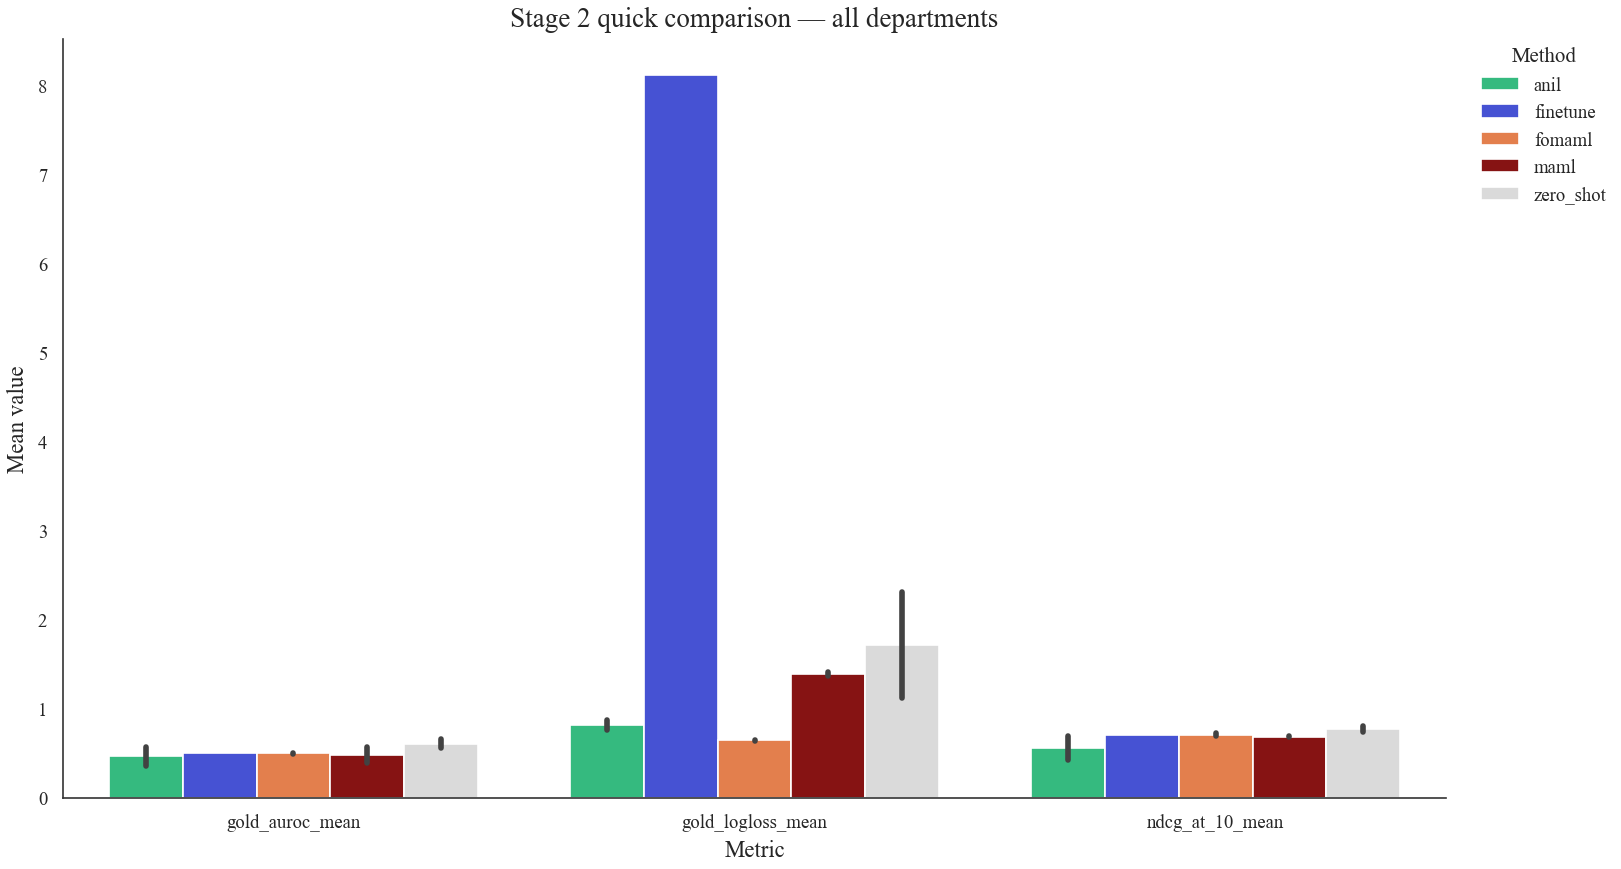

In [17]:
# ── Quick method comparison plot ─────────────────────────────────────────────
# Diagnostic figure only — not a thesis figure. For publication plots see NB17.1.
if not experiment_summary.empty:
    _quick_df = experiment_summary.copy()
    # Filter to non-Stage-2b experiments for clean method comparison
    if "augmentation_method" in _quick_df.columns:
        _quick_df = _quick_df[_quick_df["augmentation_method"].isna()].copy()

    _metric_columns = [
        c for c in ["gold_auroc_mean", "gold_logloss_mean", "ndcg_at_10_mean"]
        if c in _quick_df.columns
    ]
    if _metric_columns and "method" in _quick_df.columns:
        fig, ax = plot_stage2_metric_comparison(
            _quick_df,
            metrics=_metric_columns,
            group_col="method",
            title="Stage 2 quick comparison — all departments",
        )
    else:
        display(_quick_df.head(20))
else:
    print("No saved experiment results available yet.")

In [18]:
# ── Quick summary table ───────────────────────────────────────────────────────
if not experiment_summary.empty:
    _metric_cols = [c for c in experiment_summary.columns if c.endswith("_mean")]
    _key_cols = [
        "experiment_id", "method", "init_name", "n_support_pos", "n_support_neg",
        "inner_steps", "target_department", "status", "n_metric_rows",
    ]
    _display_cols = [c for c in _key_cols if c in experiment_summary.columns] + _metric_cols
    _display_cols = list(dict.fromkeys(_display_cols))

    _quick_summary = experiment_summary[_display_cols].copy()
    _sort_by = [c for c in ["method", "init_name", "n_support_pos", "inner_steps"]
               if c in _quick_summary.columns]
    if _sort_by:
        _quick_summary = _quick_summary.sort_values(_sort_by).reset_index(drop=True)
    display(_quick_summary)
else:
    print("Run experiments first to populate the summary.")

,experiment_id,method,init_name,n_support_pos,n_support_neg,inner_steps,target_department,status,n_metric_rows,gold_auroc_mean,...,precision_at_10_mean,recall_at_10_mean,ndcg_at_10_mean,precision_at_20_mean,recall_at_20_mean,ndcg_at_20_mean,pred_mean_mean,pred_std_mean,frac_near_zero_mean,frac_near_one_mean
0,stage2__init-A_weak_only__method-anil__kpos-1_...,anil,A_weak_only,1,1,3,Logistics,success,3.0,0.459596,...,0.600000,0.570707,0.693198,0.642157,1.000000,0.905613,0.455641,0.082013,0.000000,0.000000
1,stage2__init-A_weak_only__method-anil__kpos-1_...,anil,A_weak_only,1,1,3,Logistics,success,5.0,0.479924,...,0.620000,0.559091,0.711048,0.655294,1.000000,0.916141,0.441392,0.078069,0.000000,0.000000
2,stage2__init-A_weak_only__method-anil__kpos-1_...,anil,A_weak_only,1,1,3,Logistics,success,20.0,0.491614,...,0.600000,0.592045,0.703516,0.630867,1.000000,0.903805,0.517722,0.080041,0.000000,0.006250
3,stage2__init-A_weak_only__method-anil__kpos-1_...,anil,A_weak_only,1,1,3,Logistics,success,20.0,0.481510,...,0.605000,0.631818,0.710244,0.633341,1.000000,0.895449,0.537698,0.090944,0.000000,0.006250
4,stage2__init-A_weak_only__method-anil__kpos-1_...,anil,A_weak_only,1,1,3,Logistics,success,20.0,0.487497,...,0.600000,0.627652,0.716796,0.633341,1.000000,0.904920,0.572496,0.102495,0.000000,0.000000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
230,stage2__init-C_hybrid__method-zero_shot__kpos-...,zero_shot,C_hybrid,1,1,5,Packaging Material,success,20.0,0.805437,...,1.000000,0.220469,1.000000,0.980000,0.431636,0.986955,0.749535,0.231578,0.000000,0.317691
231,stage2__init-C_hybrid__method-zero_shot__kpos-...,zero_shot,C_hybrid,2,2,3,Logistics,success,20.0,0.669518,...,0.737738,0.916623,0.910472,0.744766,1.000000,0.956749,0.203534,0.109422,0.162899,0.000000
232,stage2__init-C_hybrid__method-zero_shot__kpos-...,zero_shot,C_hybrid,2,2,3,Packaging Material,success,20.0,NaN,...,1.000000,0.277083,1.000000,1.000000,0.554167,1.000000,0.797859,0.205050,0.000000,0.396528
233,stage2__init-C_hybrid__method-zero_shot__kpos-...,zero_shot,C_hybrid,2,2,5,Logistics,success,20.0,0.669518,...,0.737738,0.916623,0.910472,0.744766,1.000000,0.956749,0.203534,0.109422,0.162899,0.000000


In [19]:
# ── Collapse / sanity check ───────────────────────────────────────────────────
# Scans all experiment folders in EXPERIMENT_ROOT for prediction collapse.
import os
_sanity_rows = []
for _exp_dir in sorted(EXPERIMENT_ROOT.iterdir()):
    if not _exp_dir.is_dir():
        continue
    _stats_path = _exp_dir / "prediction_stats.csv"
    _row = {"experiment_id": _exp_dir.name, "stats_exists": _stats_path.exists()}
    if _stats_path.exists():
        try:
            _stats = pd.read_csv(_stats_path)
            _row["n_episodes"] = len(_stats)
            _row["collapse_rate"] = (
                float(_stats["collapsed"].mean()) if "collapsed" in _stats.columns else None
            )
            _row["pred_std_mean"] = (
                float(_stats["pred_std"].mean()) if "pred_std" in _stats.columns else None
            )
        except Exception as _exc:
            _row["stats_read_error"] = str(_exc)
    _sanity_rows.append(_row)

_sanity_df = pd.DataFrame(_sanity_rows)
if _sanity_df.empty:
    print("No experiment folders found.")
else:
    _high_collapse = _sanity_df[
        _sanity_df.get("collapse_rate", pd.Series(dtype=float)).fillna(0) > 0.5
    ]
    if not _high_collapse.empty:
        print(f"{len(_high_collapse)} experiment(s) show > 50% collapsed episodes. "
              "Inspect NB17.1 collapse diagnostics.")
    else:
        print("No high-collapse experiments detected.")
    display(_sanity_df.sort_values("collapse_rate", ascending=False, na_position="last"))

87 experiment(s) show > 50% collapsed episodes. Inspect NB17.1 collapse diagnostics.


,experiment_id,stats_exists,n_episodes,collapse_rate,pred_std_mean
352,stage2__init-random__method-anil__kpos-2__kneg...,True,5.0,1.0,1.562388e-10
299,stage2__init-C_hybrid__method-maml__kpos-2__kn...,True,20.0,1.0,5.300576e-04
295,stage2__init-C_hybrid__method-maml__kpos-2__kn...,True,20.0,1.0,2.693668e-18
294,stage2__init-C_hybrid__method-maml__kpos-1__kn...,True,20.0,1.0,7.263856e-04
121,stage2__init-A_weak_only__method-fomaml__kpos-...,True,20.0,1.0,2.396681e-03
...,...,...,...,...,...
362,test__A_weak_only__Logistics,False,NaN,NaN,NaN
363,test__B_gold_only__Logistics,False,NaN,NaN,NaN
364,test__C_hybrid__Logistics,False,NaN,NaN,NaN
365,test__D_hybrid_unweighted__Logistics,False,NaN,NaN,NaN


## 10. Artifact / Accounting Checks

Scans *all* experiment folders in `models/stage_2/experiments/` for completeness. Missing `metrics.csv` or `predictions.csv` indicates a failed run that should be re-executed with `FORCE_RERUN = True`.

A missing `history.csv` is expected for `zero_shot` (no outer-loop training) but is a warning sign for adaptive methods.

For Stage 2b accounting validation run:
```bash
python experiments/validate_stage2b_accounting.py
```

In [20]:
# ── Artifact verification — scans all experiment folders ─────────────────────
_artifact_names = [
    "resolved_config.yaml", "metrics.csv", "predictions.csv",
    "history.csv", "stage2_result_summary.json", "prediction_stats.csv",
]
_stage2b_artifact_names = [
    "support_accounting.csv", "stage2b_config.json",
]

_artifact_rows = []
for _exp_dir in sorted(EXPERIMENT_ROOT.iterdir()):
    if not _exp_dir.is_dir():
        continue
    _is_s2b = "synprop-" in _exp_dir.name or "gen-" in _exp_dir.name
    _row = {"experiment_id": _exp_dir.name}
    for _name in _artifact_names:
        _row[_name] = (_exp_dir / _name).exists()
    if _is_s2b:
        for _name in _stage2b_artifact_names:
            _row[_name] = (_exp_dir / _name).exists()
    _artifact_rows.append(_row)

_artifact_df = pd.DataFrame(_artifact_rows)
print(f"Total experiment folders: {len(_artifact_df)}")
_s2b_mask = _artifact_df["experiment_id"].str.contains("synprop-|gen-", na=False)
print(f"  Stage 2  (non-Stage-2b): {(~_s2b_mask).sum()}")
print(f"  Stage 2b (synth sweep):  {_s2b_mask.sum()}")
print()
display(_artifact_df)

Total experiment folders: 367
  Stage 2  (non-Stage-2b): 255
  Stage 2b (synth sweep):  112



,experiment_id,resolved_config.yaml,metrics.csv,predictions.csv,history.csv,stage2_result_summary.json,prediction_stats.csv,support_accounting.csv,stage2b_config.json
0,stage2__init-A_weak_only__method-anil__kpos-10...,False,False,False,False,False,False,NaN,NaN
1,stage2__init-A_weak_only__method-anil__kpos-10...,False,False,False,False,False,False,NaN,NaN
2,stage2__init-A_weak_only__method-anil__kpos-1_...,True,True,True,True,True,True,NaN,NaN
3,stage2__init-A_weak_only__method-anil__kpos-1_...,True,True,True,True,True,True,True,True
4,stage2__init-A_weak_only__method-anil__kpos-1_...,True,True,True,True,True,True,True,True
...,...,...,...,...,...,...,...,...,...
362,test__A_weak_only__Logistics,False,False,False,False,False,False,NaN,NaN
363,test__B_gold_only__Logistics,False,False,False,False,False,False,NaN,NaN
364,test__C_hybrid__Logistics,False,False,False,False,False,False,NaN,NaN
365,test__D_hybrid_unweighted__Logistics,False,False,False,False,False,False,NaN,NaN


In [21]:
# ── Stage 2b accounting health summary ───────────────────────────────────────
_smote_mask = _artifact_df["experiment_id"].str.contains("gen-smote_nc", na=False)
_smote_df = _artifact_df[_smote_mask]

if _smote_df.empty:
    print("No Stage 2b smote_nc experiment folders found.")
else:
    _has_acct = _smote_df.get("support_accounting.csv", pd.Series(dtype=bool))
    _has_cfg  = _smote_df.get("stage2b_config.json",    pd.Series(dtype=bool))
    print(f"smote_nc folders:                {len(_smote_df)}")
    print(f"  with support_accounting.csv:  {_has_acct.sum()} / {len(_smote_df)}")
    print(f"  with stage2b_config.json:     {_has_cfg.sum()} / {len(_smote_df)}")
    _missing_acct = _smote_df[~_has_acct.astype(bool)]["experiment_id"].tolist()
    _stale = _smote_df[~_has_cfg.astype(bool)]["experiment_id"].tolist()
    if _missing_acct:
        print(f"\n\u26a0  {len(_missing_acct)} smote_nc folder(s) missing "
              "support_accounting.csv — rerun with --force-rerun")
        for _mid in _missing_acct[:5]:
            print(f"    {_mid}")
    if _stale:
        print(f"\n\u26a0  {len(_stale)} stale (pre-accounting-fix) folder(s) "
              "lack stage2b_config.json — rerun with --force-rerun")
    if not _missing_acct and not _stale:
        print("\n\u2713 All smote_nc folders have accounting artifacts.")
    print()
    print("For full accounting validation run:")
    print("  python experiments/validate_stage2b_accounting.py")

smote_nc folders:                70
  with support_accounting.csv:  32 / 70
  with stage2b_config.json:     32 / 70

⚠  38 smote_nc folder(s) missing support_accounting.csv — rerun with --force-rerun
    stage2__init-A_weak_only__method-anil__kpos-1__kneg-1__steps-3__target-Logistics__synprop-0.9__gen-smote_nc
    stage2__init-A_weak_only__method-anil__kpos-1__kneg-1__steps-3__target-Logistics__synprop-1__gen-smote_nc
    stage2__init-A_weak_only__method-anil__kpos-1__kneg-1__steps-3__target-Packaging-Material__synprop-0.9__gen-smote_nc
    stage2__init-A_weak_only__method-anil__kpos-1__kneg-1__steps-3__target-Packaging-Material__synprop-1__gen-smote_nc
    stage2__init-A_weak_only__method-anil__kpos-1__kneg-1__steps-5__target-Logistics__synprop-0.9__gen-smote_nc

⚠  38 stale (pre-accounting-fix) folder(s) lack stage2b_config.json — rerun with --force-rerun

For full accounting validation run:
  python experiments/validate_stage2b_accounting.py
